In [30]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from scipy.spatial.distance import cdist
from mpl_toolkits.mplot3d import Axes3D
import seaborn as sns

In [31]:
data = pd.read_csv("Cust_Segmentation.csv")
print(data.head())

   Customer Id  Age  Edu  Years Employed  Income  Card Debt  Other Debt  \
0            1   41    2               6      19      0.124       1.073   
1            2   47    1              26     100      4.582       8.218   
2            3   33    2              10      57      6.111       5.802   
3            4   29    2               4      19      0.681       0.516   
4            5   47    1              31     253      9.308       8.908   

   Defaulted Address  DebtIncomeRatio  
0        0.0  NBA001              6.3  
1        0.0  NBA021             12.8  
2        1.0  NBA013             20.9  
3        0.0  NBA009              6.3  
4        0.0  NBA008              7.2  


In [32]:
df = data.select_dtypes(include=[np.number])
df = df.dropna()

In [33]:
scaler = StandardScaler()
X = scaler.fit_transform(df)

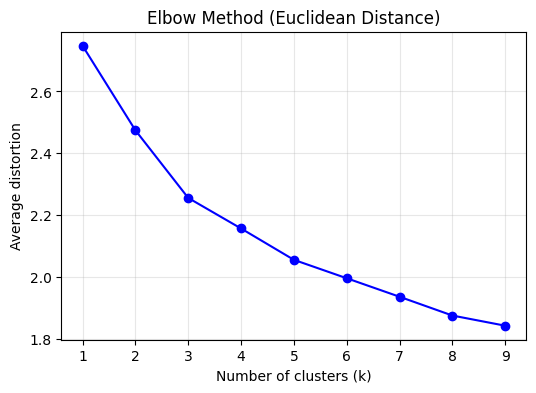

In [34]:
distortions = []
K = range(1, 10)
for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X)
    distortions.append(sum(np.min(cdist(X, kmeans.cluster_centers_, 'euclidean'), axis=1)) / X.shape[0])

plt.figure(figsize=(6, 4))
plt.plot(K, distortions, 'bo-')
plt.title("Elbow Method (Euclidean Distance)")
plt.xlabel("Number of clusters (k)")
plt.ylabel("Average distortion")
plt.grid(alpha=0.3)
plt.show()

In [35]:
k_euclidean = KMeans(n_clusters=3, random_state=42)
labels_euclidean = k_euclidean.fit_predict(X)

In [36]:
def manhattan_kmeans(X, n_clusters, max_iter=100):
    np.random.seed(42)
    centers = X[np.random.choice(range(len(X)), n_clusters, replace=False)]
    for _ in range(max_iter):
        distances = np.abs(X[:, np.newaxis] - centers).sum(axis=2)
        labels = np.argmin(distances, axis=1)
        new_centers = np.array([X[labels == j].mean(axis=0) for j in range(n_clusters)])
        if np.allclose(centers, new_centers):
            break
        centers = new_centers
    return labels, centers

labels_manhattan, centers_manhattan = manhattan_kmeans(X, 3)


In [37]:
df["Cluster_Euclidean"] = labels_euclidean
df["Cluster_Manhattan"] = labels_manhattan

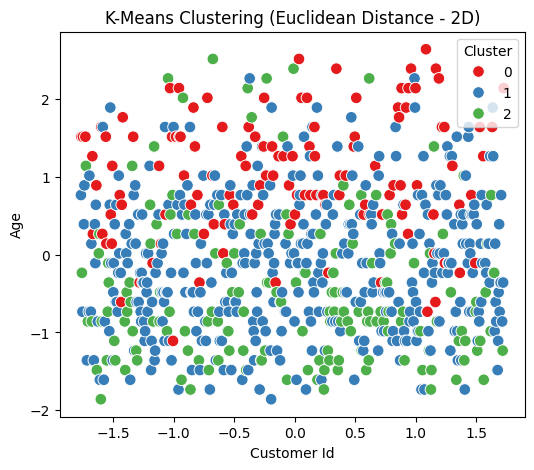

In [38]:
plt.figure(figsize=(6, 5))
sns.scatterplot(
    x=X[:, 0], y=X[:, 1],
    hue=labels_euclidean,
    palette='Set1', s=70
)
plt.title("K-Means Clustering (Euclidean Distance - 2D)")
plt.xlabel(df.columns[0])
plt.ylabel(df.columns[1])
plt.legend(title='Cluster')
plt.show()

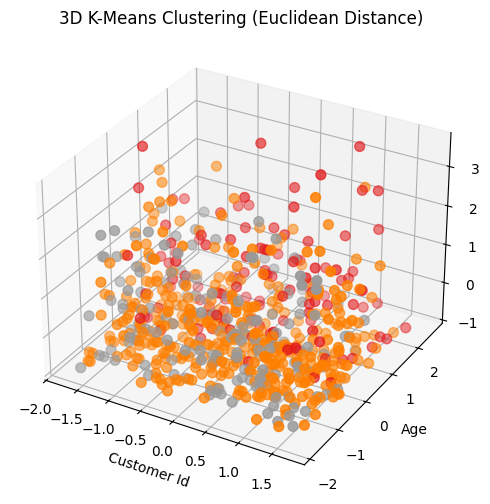

In [39]:
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(X[:, 0], X[:, 1], X[:, 2], c=labels_euclidean, cmap='Set1', s=50)
ax.set_title("3D K-Means Clustering (Euclidean Distance)")
ax.set_xlabel(df.columns[0])
ax.set_ylabel(df.columns[1])
ax.set_zlabel(df.columns[2])
plt.show()

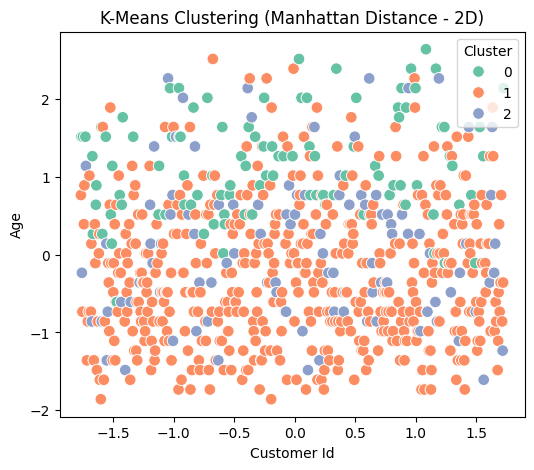

In [40]:
plt.figure(figsize=(6, 5))
sns.scatterplot(
    x=X[:, 0], y=X[:, 1],
    hue=labels_manhattan,
    palette='Set2', s=70
)
plt.title("K-Means Clustering (Manhattan Distance - 2D)")
plt.xlabel(df.columns[0])
plt.ylabel(df.columns[1])
plt.legend(title='Cluster')
plt.show()

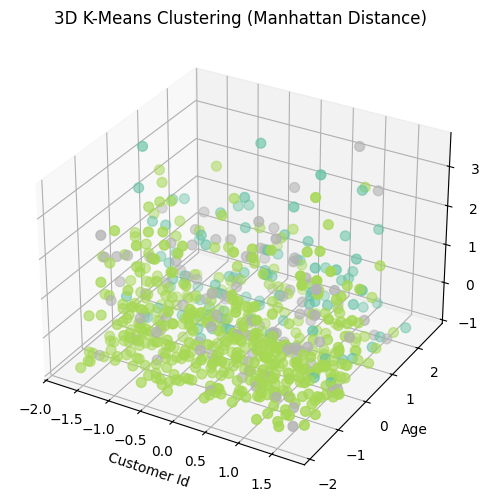

In [41]:
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(X[:, 0], X[:, 1], X[:, 2],
           c=labels_manhattan, cmap='Set2', s=50)
ax.set_title("3D K-Means Clustering (Manhattan Distance)")
ax.set_xlabel(df.columns[0])
ax.set_ylabel(df.columns[1])
ax.set_zlabel(df.columns[2])
plt.show()